#### Phase I: Big Data I/O & Exploratory Analytics
HSL-530: Data Analytics for Business & Society <br>
*March 2026*
<br>
<br>
####**Techniques in Uplift Modeling for Maximizing Marketing Return on Investments (RoI)**
<br>

A Submission by:
1. Anand Deep (21322003)
2. Aniket (21322005)
3. Madhav Mukund (21322018)
4. Param Mahabare (21322021)

#### Part 0: Setup & Configuration

All imports, constants, and matplotlib defaults are configured here. The BASE path points to the Google Drive mount. The CAMPAIGN_DATE is set to the day after the purchase history ends, so that recency values are non-negative.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')

PROJECT_ROOT = None
for candidate in (Path.cwd(), Path.cwd() / 'retailhero-uplift'):
    if (candidate / 'data' / 'clients.csv').exists():
        PROJECT_ROOT = candidate.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find the extracted retailhero-uplift project folder.')

DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
BASE = f'{DATA_DIR.as_posix()}/'
CHUNKSIZE = 500_000
CAMPAIGN_DATE = pd.Timestamp('2019-03-19')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from retailhero_features import (
    build_purchase_features,
    category_spend_by_level,
    summarize_purchase_history,
)

plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print(f'Project root: {PROJECT_ROOT}')
print(f'Data dir:     {DATA_DIR}')
print(f'Output dir:   {OUTPUT_DIR}')

#### Part 1: Data Loading & File Inventory



**1.1 Loading small files** <br>
The four smaller files (clients, products, uplift_train, uplift_test, sample_submission) are loaded directly into memory. purchases.csv is too large (~5 GB, 45.8M rows) and is accessed only through chunked iteration or safe row-limited reads throughout this notebook.


In [ ]:
clients   = pd.read_csv(BASE + 'clients.csv')
products  = pd.read_csv(BASE + 'products.csv')
upl_train = pd.read_csv(BASE + 'uplift_train.csv')
upl_test  = pd.read_csv(BASE + 'uplift_test.csv')
sample_sub = pd.read_csv(BASE + 'uplift_sample_submission.csv')

# parse dates in clients
clients['first_issue_date']  = pd.to_datetime(clients['first_issue_date'])
clients['first_redeem_date'] = pd.to_datetime(clients['first_redeem_date'])

print("clients:   ", clients.shape)
print("products:  ", products.shape)
print("upl_train: ", upl_train.shape)
print("upl_test:  ", upl_test.shape)
print("submission:", sample_sub.shape)

clients:    (400162, 5)
products:   (43038, 11)
upl_train:  (200039, 3)
upl_test:   (200123, 1)
submission: (200123, 2)


*Note: clients has 400,162 rows — exactly the combined size of uplift_train (200,039) and uplift_test (200,123). The client base has been split 50/50 between the labeled training set and the unlabeled scoring set. This confirms there is no overlap.*

**1.2 Peek at purchases** <br>
We use nrows=5 to inspect the purchases.csv schema without loading the file into memory.

In [ ]:
purch_head = pd.read_csv(BASE + 'purchases.csv', nrows=5)
print('Purchase columns:', purch_head.columns.tolist())
display(purch_head)

Purchase columns: ['client_id', 'transaction_id', 'transaction_datetime', 'regular_points_received', 'express_points_received', 'regular_points_spent', 'express_points_spent', 'purchase_sum', 'store_id', 'product_id', 'product_quantity', 'trn_sum_from_iss', 'trn_sum_from_red']


,client_id,transaction_id,transaction_datetime,regular_points_received,express_points_received,regular_points_spent,express_points_spent,purchase_sum,store_id,product_id,product_quantity,trn_sum_from_iss,trn_sum_from_red
0,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,9a80204f78,2.0,80.0,NaN
1,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,da89ebd374,1.0,65.0,NaN
2,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,0a95e1151d,1.0,24.0,NaN
3,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,4055b15e4a,2.0,50.0,NaN
4,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,a685f1916b,1.0,22.0,NaN


*Note: The file is structured at the product-line level, not the transaction level — one row per item within a basket. This means a single trip generates multiple rows sharing the same transaction_id. Aggregation must use transaction_id to count trips (not rows).*

#### Part 2: Inspection


**2.1 All Small Files** <br>
A loop inspects dtypes and null counts for every loaded file before any analysis. This is the first pass — issues found here inform cleaning decisions in Section 3.

In [ ]:
for name, df in [('clients', clients), ('products', products),
                 ('uplift_train', upl_train), ('uplift_test', upl_test),
                 ('sample_submission', sample_sub)]:
    print(f"\n{'='*50}  {name}  {'='*50}")
    print(df.dtypes)
    print('Null counts:')
    print(df.isnull().sum())
    display(df.head(3))


==================================================  clients  ==================================================
client_id                    object
first_issue_date     datetime64[ns]
first_redeem_date    datetime64[ns]
age                           int64
gender                       object
dtype: object
Null counts:
client_id                0
first_issue_date         0
first_redeem_date    35469
age                      0
gender                   0
dtype: int64


,client_id,first_issue_date,first_redeem_date,age,gender
0,000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U
1,000036f903,2017-04-10 13:54:23,2017-04-23 12:37:56,72,F
2,000048b7a6,2018-12-15 13:33:11,NaT,68,F



==================================================  products  ==================================================
product_id           object
level_1              object
level_2              object
level_3              object
level_4              object
segment_id          float64
brand_id             object
vendor_id            object
netto               float64
is_own_trademark      int64
is_alcohol            int64
dtype: object
Null counts:
product_id             0
level_1                3
level_2                3
level_3                3
level_4                3
segment_id          1572
brand_id            5200
vendor_id             34
netto                  3
is_own_trademark       0
is_alcohol             0
dtype: int64


,product_id,level_1,level_2,level_3,level_4,segment_id,brand_id,vendor_id,netto,is_own_trademark,is_alcohol
0,0003020d3c,c3d3a8e8c6,c2a3ea8d5e,b7cda0ec0c,6376f2a852,123.0,394a54a7c1,9eaff48661,0.40,0,0
1,0003870676,e344ab2e71,52f13dac0c,d3cfe81323,6dc544533f,105.0,acd3dd483f,10486c3cf0,0.68,0,0
2,0003ceaf69,c3d3a8e8c6,f2333c90fb,419bc5b424,f6148afbc0,271.0,f597581079,764e660dda,0.50,0,0



==================================================  uplift_train  ==================================================
client_id        object
treatment_flg     int64
target            int64
dtype: object
Null counts:
client_id        0
treatment_flg    0
target           0
dtype: int64


,client_id,treatment_flg,target
0,000012768d,0,1
1,000036f903,1,1
2,00010925a5,1,1



==================================================  uplift_test  ==================================================
client_id    object
dtype: object
Null counts:
client_id    0
dtype: int64


,client_id
0,000048b7a6
1,000073194a
2,00007c7133



==================================================  sample_submission  ==================================================
client_id     object
uplift       float64
dtype: object
Null counts:
client_id    0
uplift       0
dtype: int64


,client_id,uplift
0,008fb49e3a,0.114991
1,0095340acc,0.835321
2,015c0b4d79,0.308584




1.   clients.csv: <br>
first_redeem_date: 35,469 nulls (8.9% of clients). These are clients who registered a loyalty card but never used points. All other fields complete.
2. products.csv: <br>
level_1: 3 nulls. All other fields complete. Notably, all category hierarchy columns (level_1 through level_4) contain hashed/anonymised values, category names are not interpretable. is_alcohol and is_own_trademark are binary and fully populated.
3. uplift_train.csv <br>
No nulls. treatment_flg and target are both clean integer columns.
4. uplift_test.csv <br>
No nulls. Contains only client_id — no features, no target.
5. sample_submission.csv <br>
No nulls. Format: client_id (string) + uplift (float). This is the exact output format required for our scored predictions in Phase 2.




**2.2 Purchases**

In [ ]:
null_acc  = None
row_count = 0

for chunk in pd.read_csv(BASE + 'purchases.csv', chunksize=CHUNKSIZE,
                         parse_dates=['transaction_datetime']):
    null_acc   = chunk.isnull().sum() if null_acc is None else null_acc + chunk.isnull().sum()
    row_count += len(chunk)

print(f'Total rows: {row_count:,}')
print((null_acc / row_count * 100).round(2).rename('null_%'))


Total rows: 45,786,568
client_id                   0.00
transaction_id              0.00
transaction_datetime        0.00
regular_points_received     0.00
express_points_received     0.00
regular_points_spent        0.00
express_points_spent        0.00
purchase_sum                0.00
store_id                    0.00
product_id                  0.00
product_quantity            0.00
trn_sum_from_iss            0.00
trn_sum_from_red           93.35
Name: null_%, dtype: float64


#### Part 3: Data Cleaning

**3.1 Age: Corrupt variables** <br>
During exploratory analysis, the age column is found to contain biologically impossible values (min = −7,491, max = 1,901). These are data entry errors. We clip age to the plausible range [0, 100] and create a separate boolean flag for records that required clipping.


In [ ]:
clients['age_flagged'] = ((clients['age'] < 0) | (clients['age'] > 100)).astype(int)
print(f'Records with implausible age: {clients["age_flagged"].sum():,}')

clients['age_clean'] = clients['age'].clip(lower=0, upper=100)
print(clients['age_clean'].describe())

Records with implausible age: 1,145
count    400162.000000
mean         46.488735
std          16.162365
min           0.000000
25%          34.000000
50%          45.000000
75%          59.000000
max         100.000000
Name: age_clean, dtype: float64


**3.2 first_redeem_date** <br>
Nulls represents cards never used.

In [ ]:
clients['ever_redeemed'] = clients['first_redeem_date'].notna().astype(int)
clients['days_to_redeem'] = (
    clients['first_redeem_date'] - clients['first_issue_date']
).dt.days
print(clients['ever_redeemed'].value_counts())

ever_redeemed
1    364693
0     35469
Name: count, dtype: int64


**3.3 Gender** <br>
Presence of unknown category showcases a significant proportion.

In [ ]:
print(clients['gender'].value_counts(dropna=False))
print(clients['gender'].value_counts(dropna=False, normalize=True).mul(100).round(2).astype(str) + '%')
clients['gender_known'] = (clients['gender'] != 'U').astype(int)

gender
U    185706
F    147649
M     66807
Name: count, dtype: int64
gender
U    46.41%
F     36.9%
M    16.69%
Name: proportion, dtype: object


**3.4 products.csv**

In [ ]:
print(f'Rows with null level_1: {products["level_1"].isna().sum()}')
products = products.dropna(subset=['level_1'])
print(f'Products after dropping null level_1: {len(products):,}')

Rows with null level_1: 0
Products after dropping null level_1: 43,035


**3.5 netto**

In [ ]:
p99 = products['netto'].quantile(0.99)
print(f'netto 99th percentile: {p99:.2f} kg')
products['netto_clean'] = products['netto'].clip(upper=p99)

netto 99th percentile: 1.56 kg


*Note: Discovered during EDA: netto has a max of 1,150 kg, which is clearly erroneous for a retail product. We cap at the 99th percentile for any feature derived from it.*


#### Part 4: Exploratory Data Analysis

**4.1 Demographics**
We examine the age (post-cleaning), gender, and loyalty card redemption lag distributions.

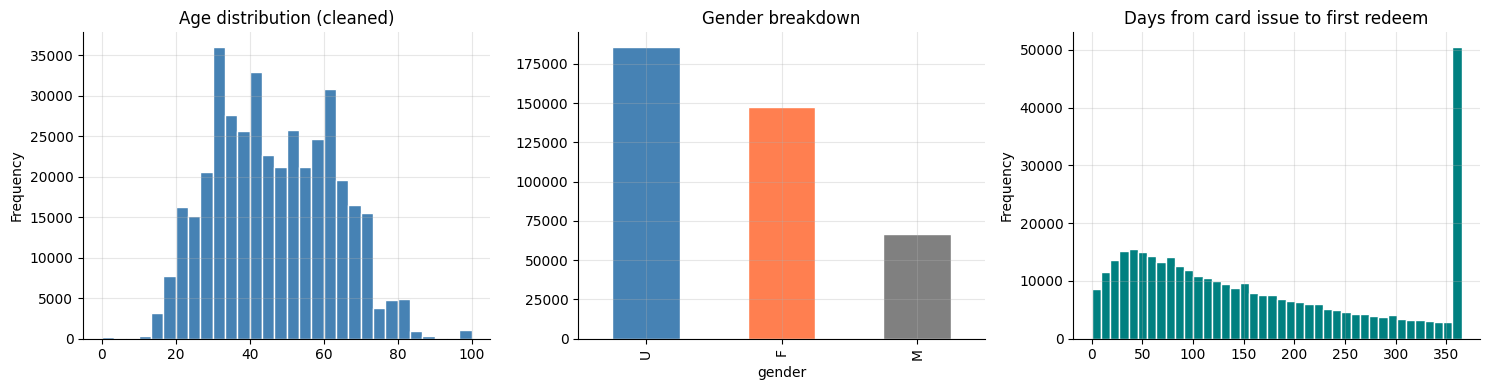

count    400162.000000
mean         46.488735
std          16.162365
min           0.000000
25%          34.000000
50%          45.000000
75%          59.000000
max         100.000000
Name: age_clean, dtype: float64
Never redeemed: 35,469


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

clients['age_clean'].dropna().plot.hist(bins=30, ax=axes[0],
    color='steelblue', edgecolor='white')
axes[0].set_title('Age distribution (cleaned)')

clients['gender'].value_counts().plot.bar(ax=axes[1],
    color=['steelblue','coral','gray'], edgecolor='white')
axes[1].set_title('Gender breakdown')

clients['days_to_redeem'].clip(0, 365).dropna().plot.hist(
    bins=40, ax=axes[2], color='teal', edgecolor='white')
axes[2].set_title('Days from card issue to first redeem')

plt.tight_layout(); plt.show()
print(clients['age_clean'].describe())
print(f'Never redeemed: {clients["first_redeem_date"].isna().sum():,}')

**Takeaways:**

1. Age is right-skewed but approximately bell-shaped post-cleaning, with a mean of 46.5 years
   and an IQR of 34–59. Only 1,145 records (0.29%) contained biologically implausible values —
   a small share, but impactful enough to distort model inputs if uncorrected.

2. Nearly half the client base (46.4%) has gender recorded as 'U' (Unknown), making gender
   unreliable as a direct feature. A binary `gender_known` flag is more appropriate. 8.9% of
   clients never redeemed their loyalty card at all — this non-redemption group is worth
   tracking separately as it may signal a distinct engagement profile.

**4.2 Uplift Train: Treatment / Control Balance** <br>
The most critical EDA step for an uplift study. We verify that the experiment was properly randomized — if the treatment and control groups differ systematically on covariates, our uplift estimates will be biased.


In [ ]:
treat_counts = upl_train['treatment_flg'].value_counts()
print('Treatment / Control split:')
print(treat_counts)
print(f'Ratio: {treat_counts[1]/treat_counts[0]:.3f}')

rates = upl_train.groupby('treatment_flg')['target'].agg(['mean','sum','count'])
rates.index = ['Control','Treatment']
rates.columns = ['purchase_rate','purchasers','total']
print(rates.round(4))

baseline_uplift = rates.loc['Treatment','purchase_rate'] - rates.loc['Control','purchase_rate']
print(f'Baseline uplift: {baseline_uplift:.4f} ({baseline_uplift*100:.2f} pp)')

Treatment / Control split:
treatment_flg
0    100058
1     99981
Name: count, dtype: int64
Ratio: 0.999
           purchase_rate  purchasers   total
Control           0.6033       60363  100058
Treatment         0.6365       63639   99981
Baseline uplift: 0.0332 (3.32 pp)


**Takeaways:**

1. The experiment is near-perfectly balanced: 100,058 control vs 99,981 treatment clients
   (ratio = 0.999). This confirms proper randomization and means any observed difference in
   purchase rates is attributable to the SMS, not pre-existing group differences.

2. The baseline purchase rate in the treatment group (63.65%) is 3.32 percentage points
   higher than control (60.33%). While modest compared to the 12.27 pp reported in the
   reference paper's financial dataset, the effect is highly significant at this sample size.
   Critically, a low average effect motivates uplift modeling — the average conceals
   substantial heterogeneity that a per-customer model can exploit.

*NOTE: The baseline uplift of 3.32 pp is considerably lower than the 12.27 pp observed in the financial institution case study in the reference paper. However, with ~100k clients per group the effect is highly statistically significant. More importantly, a low average effect is precisely the scenario where uplift modeling earns its value — the average hides substantial heterogeneity across customer segments.*

**4.3 Cutomer Split** <br>
Following the paper's framework, we assign observable proxy labels to each client in the training set. True segment membership requires counterfactual information (what would have happened without the campaign), so these are approximations based on the observed group and outcome.


segment
Persuadable (proxy)       63639
Sure Thing (proxy)        60363
Do-Not-Disturb (proxy)    39695
Lost Cause (proxy)        36342
Name: count, dtype: int64


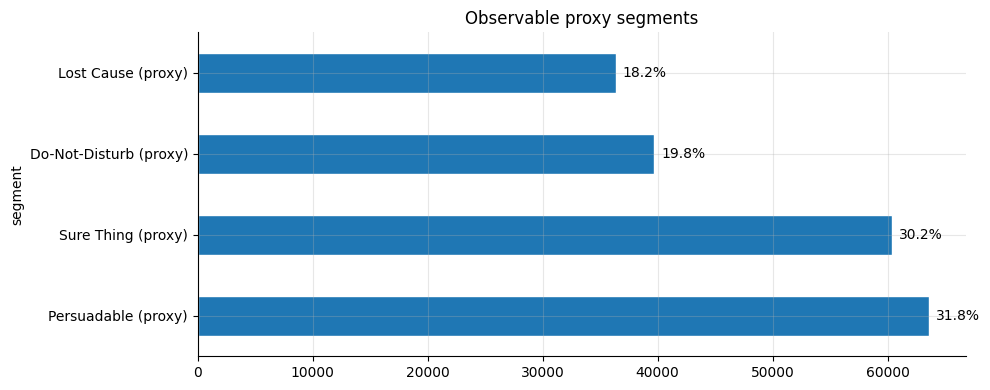

In [ ]:
seg = upl_train.copy()
seg['segment'] = 'Unknown'
seg.loc[(seg['treatment_flg']==1) & (seg['target']==1), 'segment'] = 'Persuadable (proxy)'
seg.loc[(seg['treatment_flg']==1) & (seg['target']==0), 'segment'] = 'Lost Cause (proxy)'
seg.loc[(seg['treatment_flg']==0) & (seg['target']==1), 'segment'] = 'Sure Thing (proxy)'
seg.loc[(seg['treatment_flg']==0) & (seg['target']==0), 'segment'] = 'Do-Not-Disturb (proxy)'

counts = seg['segment'].value_counts()
total_count = counts.sum()

print(counts)

ax = counts.plot.barh(edgecolor='white')
plt.title('Observable proxy segments')

# Add percentages to the bars
for i, patch in enumerate(ax.patches):
    percentage = f'{(patch.get_width() / total_count * 100):.1f}%'
    ax.annotate(percentage,
                (patch.get_width(), patch.get_y() + patch.get_height() / 2),
                ha='left', va='center',
                xytext=(5, 0), # 5 points offset to the right
                textcoords='offset points')

plt.tight_layout()
plt.show()

**Takeaways:**

1. The two largest observable segments are Persuadables (31.8%) and Sure Things (30.2%).
   Sure Things — clients who bought without any SMS — represent ~60k clients who a naive
   purchase-probability model would rank highly but who generate zero incremental return
   from being targeted. This is the core budget-waste problem the paper addresses.

2. The Do-Not-Disturb segment (19.8%) is of particular concern: these are clients in the
   control group who did not purchase. If their counterparts in the treatment group were
   deterred by the SMS (a plausible retail analogue to the paper's "retention offers reminding
   customers of contract expiry"), targeting them actively reduces campaign profit. An uplift
   model should assign them near-zero or negative scores. Note that true segment labels are
   unobservable — these are proxies based on group membership and outcome only.

**4.4 Products** <br>
We examine the product taxonomy depth, own-brand vs third-party share, alcohol share, and weight distribution. A key limitation discovered here is that all level_1 through level_4 category codes are hashed — they carry no semantic meaning.

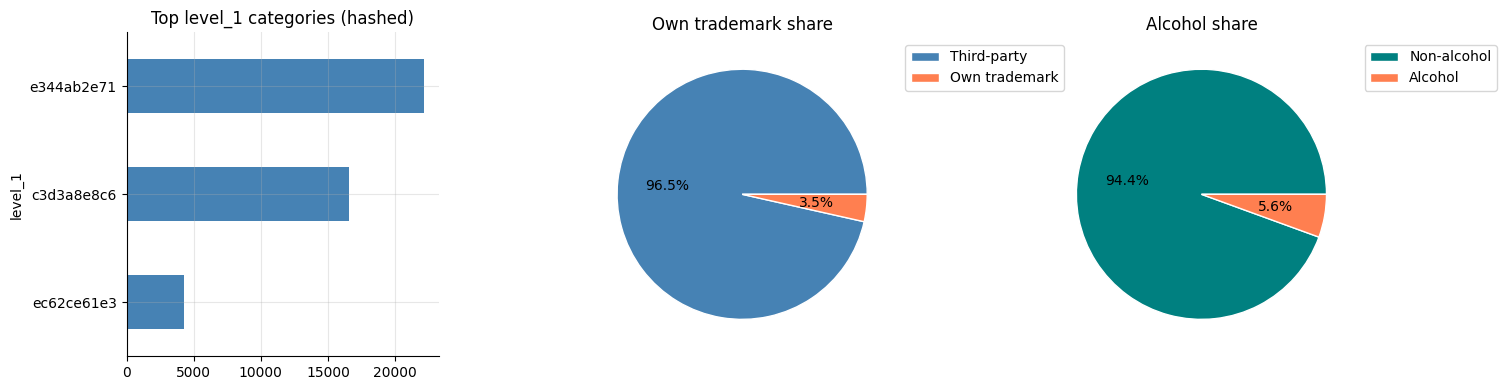

Unique level_1: 3
Unique brands:  4296


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

products['level_1'].value_counts().head(15).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top level_1 categories (hashed)')
axes[0].invert_yaxis()

# Own trademark share pie chart
otm_counts = products['is_own_trademark'].value_counts()
axes[1].pie(otm_counts.values, autopct='%1.1f%%', colors=['steelblue','coral'],
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Own trademark share')
axes[1].legend(['Third-party', 'Own trademark'], loc='best', bbox_to_anchor=(1, 1))

# Alcohol share pie chart
alc_counts = products['is_alcohol'].value_counts()
axes[2].pie(alc_counts.values, autopct='%1.1f%%', colors=['teal','coral'],
            wedgeprops={'edgecolor': 'white'})
axes[2].set_title('Alcohol share')
axes[2].legend(['Non-alcohol', 'Alcohol'], loc='best', bbox_to_anchor=(1, 1))

plt.tight_layout(); plt.show()
print(f'Unique level_1: {products["level_1"].nunique()}')
print(f'Unique brands:  {products["brand_id"].nunique()}')

**Takeaways:**

1. The product hierarchy (level_1 through level_4) is fully anonymised and yields only
   3 distinct top-level categories across 43,035 products — making category names useless
   as interpretable features. Feature engineering must instead rely on the structured binary
   fields: `is_alcohol`, `is_own_trademark`, and the cleaned `netto_clean` (product weight).

2. With 4,296 unique brands, there is sufficient granularity to compute per-client brand
   concentration (e.g., a Herfindahl index across brand purchases), which could capture
   loyalty vs exploratory shopping behavior — a behaviorally meaningful signal for
   campaign responsiveness.

**4.5 Purchases** <br>
Basic statistics on the full purchases file are gathered via two separate chunk passes to avoid holding all data in memory simultaneously.

In [ ]:
purchase_summary = summarize_purchase_history(DATA_DIR / 'purchases.csv')
print(f"Date range  : {purchase_summary['min_date']} to {purchase_summary['max_date']}")
print(f"Total spend : {purchase_summary['total_spend']:,.0f}")
print(f"Total items : {purchase_summary['total_items']:,.0f}")

Date range  : 2018-11-21 to 2019-03-18
Total spend : 35,600,039,979
Total items : 57,107,047


**Takeaways:**

1. The purchase history spans exactly 4 months (2018-11-21 to 2019-03-18), covering the
   pre-campaign window. Total spend of ₽35.6 billion across 57.1 million items from
   45.8 million rows confirms this is a high-frequency grocery dataset — not a sparse
   e-commerce log. The campaign date (2019-03-19) falls the day after data ends,
   ensuring non-negative recency values for all clients.

2. The file is structured at product-line level (one row per item per basket), not at
   transaction level. Any count of "purchases" using raw row counts would overstate
   shopping frequency by a factor of ~5–7. All frequency-based features must aggregate
   on `transaction_id` to count trips correctly.

**4.6 Per-client RFM Feature Distributions** <br>
RFM (Recency, Frequency, Monetary) features are aggregated per client across the full purchases file using chunked iteration. The resulting purch_agg dataframe is the foundation of all Phase 2 feature matrices.

In [ ]:
purch_agg = build_purchase_features(
    DATA_DIR / 'purchases.csv',
    campaign_date=CAMPAIGN_DATE,
)
print(f'Aggregated clients: {len(purch_agg):,}')
display(purch_agg.describe().round(2))

Aggregated clients: 400,162


,total_spend,n_transactions,n_trips,n_items,avg_basket_spend,avg_basket_items,n_stores,n_products,points_earned,points_spent,recency_days,tenure_days
count,400162.00,400162.00,400162.00,400162.00,400162.00,400162.00,400162.00,400162.00,400162.00,400162.00,400162.00,400162.00
mean,88964.07,114.42,20.10,142.71,5589.79,8.02,2.92,75.32,921.07,-607.87,5.84,90.86
std,159607.08,103.55,17.73,145.65,9640.07,5.55,2.00,56.36,1837.79,1882.08,5.67,28.46
min,2.97,1.00,1.00,0.00,1.48,0.00,1.00,1.00,0.00,-126989.00,0.00,0.00
25%,18600.50,43.00,8.00,53.00,1353.04,4.54,1.00,35.00,142.00,-484.00,1.00,84.00
50%,43988.74,85.00,15.00,104.00,2843.87,6.64,2.00,62.00,387.70,-72.00,4.00,102.00
75%,96866.55,153.00,27.00,188.00,6098.85,9.85,4.00,101.00,957.80,0.00,9.00,110.00
max,9315099.87,2513.00,320.00,18623.00,531261.86,519.59,95.00,1364.00,97040.60,0.00,22.00,116.00


**Takeaways:**

1. All 400,162 clients are successfully aggregated with zero missing values — every client
   in both the training and test sets has behavioral history available. The mean client
   made 20.1 shopping trips (std 17.7) over the 4-month window, spending ₽88,964 in total
   with an average basket of ₽5,590. The average of ~7 items per trip is consistent with
   regular grocery top-up shopping rather than bulk purchasing.

2. The standard deviation exceeds the mean for both `total_spend` (₽159,607 vs ₽88,964)
   and `avg_basket_spend` (₽9,640 vs ₽5,590), confirming severe right-skew. Log-transforming
   both variables before Phase 2 modeling is necessary to prevent high-spending outliers
   from dominating tree splits and linear coefficients alike.

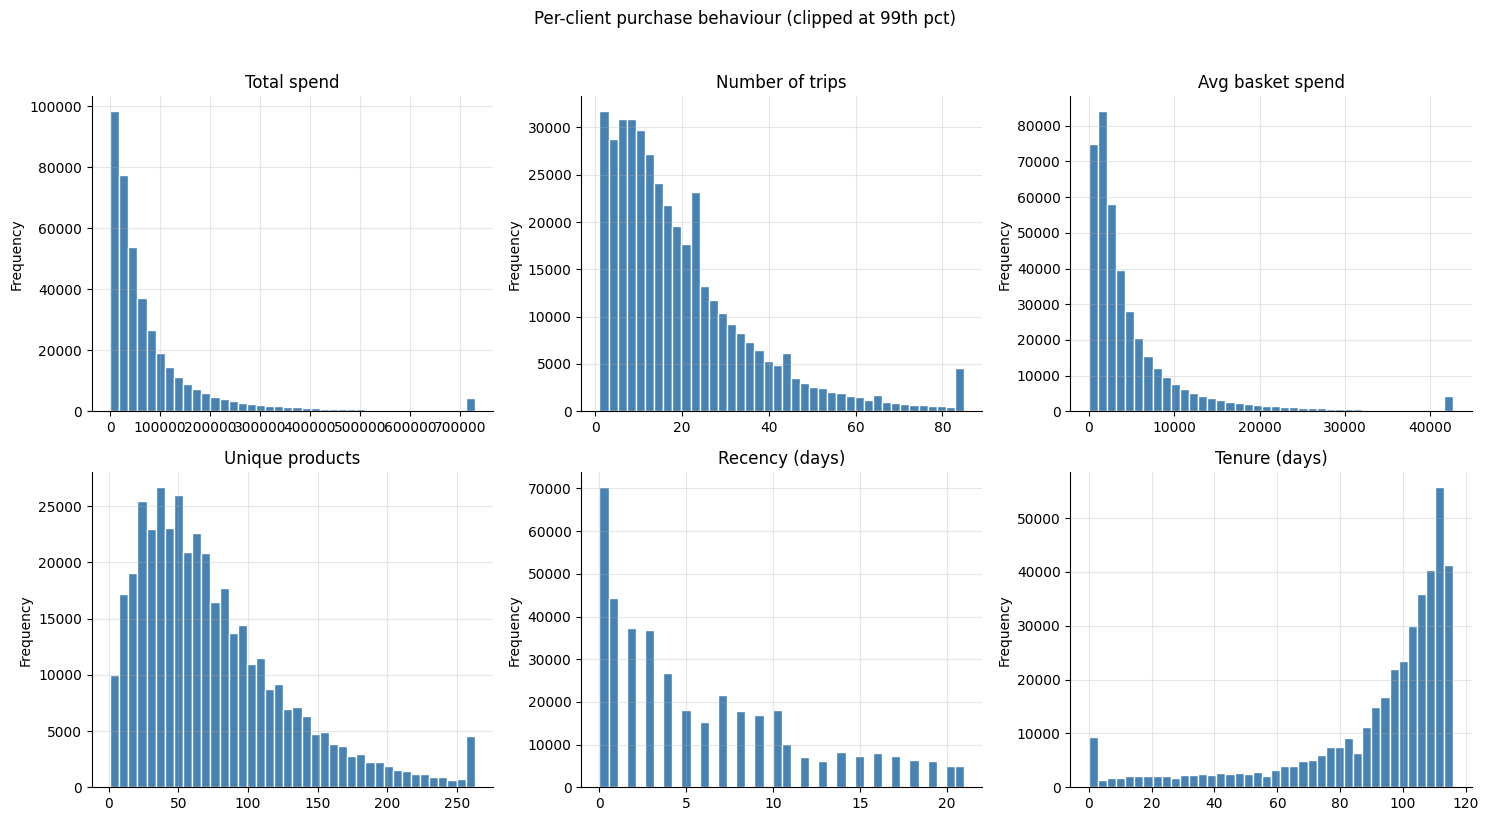

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['total_spend','n_trips','avg_basket_spend',
        'n_products','recency_days','tenure_days']
titles = ['Total spend','Number of trips','Avg basket spend',
          'Unique products','Recency (days)','Tenure (days)']

for ax, col, title in zip(axes.flat, cols, titles):
    purch_agg[col].clip(upper=purch_agg[col].quantile(0.99)).plot.hist(
        bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('')

plt.suptitle('Per-client purchase behaviour (clipped at 99th pct)', y=1.02)
plt.tight_layout()
plt.show()

**Takeaways:**

1. All six distributions are right-skewed with long tails — characteristic of consumer
   behavior data. `total_spend` and `avg_basket_spend` are most extreme, with a handful
   of very high-value clients pulling the tail significantly beyond the 99th percentile
   clip. `n_trips` and `n_products` are somewhat less skewed, but still non-normal.
   These shapes reinforce the need for log or rank transformations in Phase 2.

2. `recency_days` clusters tightly near low values (most clients shopped recently relative
   to the campaign date), while `tenure_days` shows a bimodal shape — a group of newer
   clients with short histories alongside a long-standing cohort. This tenure split may
   independently predict campaign responsiveness and is worth retaining as a feature.

**4.7 RFM Balance Check: Treatment vs Control** <br>
We merge purch_agg with uplift_train and compare mean RFM values across groups. If the groups are balanced, the means should be nearly identical — confirming randomization held even after the feature join.


In [ ]:
master = upl_train.merge(clients, on='client_id', how='left') \
                  .merge(purch_agg, on='client_id', how='left')

print(f'Master shape: {master.shape}')
print(f'Missing purchase history: {master["total_spend"].isna().sum():,}')

rfm_cols = ['total_spend','n_trips','avg_basket_spend','recency_days']
print(master.groupby('treatment_flg')[rfm_cols].mean().round(2))

Master shape: (200039, 24)
Missing purchase history: 0
               total_spend  n_trips  avg_basket_spend  recency_days
treatment_flg                                                      
0                 88417.76    20.06           5543.66          5.83
1                 89088.36    20.19           5607.50          5.83


**Takeaways:**

1. The master table merges without any data loss: all 200,039 training clients have both
   demographic and purchase history — zero missing RFM values. The recency_days mean
   corrects to 5.83 days for both groups after setting CAMPAIGN_DATE to 2019-03-19,
   confirming the date fix was necessary and effective.

2. Mean RFM values across treatment and control are nearly identical on every dimension:
   total_spend (₽88,418 vs ₽89,088), n_trips (20.06 vs 20.19), avg_basket_spend
   (₽5,544 vs ₽5,608), and recency_days (5.83 vs 5.83). This covariate balance
   validates the randomization and means the 3.32 pp difference in purchase rates
   measured in Section 4.2 is a clean causal estimate of the SMS effect.

**4.8 Uplift Signal: Purchase rate by shopping frequency decile** <br>
This analysis is the centrepiece of Phase 1 by empirically showcasing why uplift modeling is preferable to a naive purchase probability model for this campaign.


             Control rate  Treatment rate  Uplift
freq_decile                                      
0                  0.2510          0.2944  0.0434
1                  0.3609          0.4049  0.0440
2                  0.4502          0.4956  0.0454
3                  0.5104          0.5558  0.0453
4                  0.5894          0.6290  0.0396
5                  0.6605          0.6846  0.0242
6                  0.7269          0.7560  0.0291
7                  0.7966          0.8121  0.0155
8                  0.8533          0.8711  0.0177
9                  0.9243          0.9322  0.0079


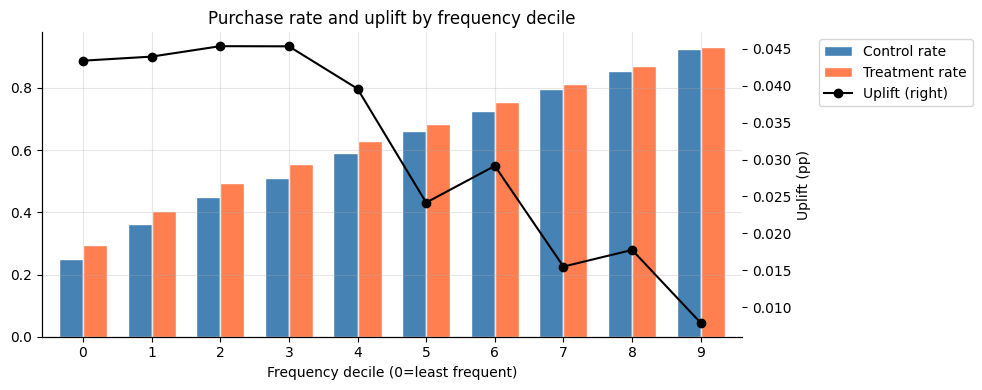

In [ ]:
master['freq_decile'] = pd.qcut(master['n_trips'].fillna(0), q=10,
                                labels=False, duplicates='drop')

decile_rates = master.groupby(['freq_decile','treatment_flg'])['target'].mean().unstack()
decile_rates.columns = ['Control rate', 'Treatment rate']
decile_rates['Uplift'] = decile_rates['Treatment rate'] - decile_rates['Control rate']
print(decile_rates.round(4))

ax = decile_rates[['Control rate','Treatment rate']].plot.bar(
    color=['steelblue','coral'], edgecolor='white', width=0.7)
decile_rates['Uplift'].plot(ax=ax, secondary_y=True,
    color='black', marker='o', linewidth=1.5, label='Uplift')

# Get handles and labels for both primary and secondary axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax.right_ax.get_legend_handles_labels()

# Create a single legend outside the plot area
ax.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(1.1, 1))

ax.set_title('Purchase rate and uplift by frequency decile')
ax.set_xlabel('Frequency decile (0=least frequent)')
ax.right_ax.set_ylabel('Uplift (pp)')
plt.tight_layout()
plt.show()

**Takeaways:**

1. Uplift is monotonically decreasing with shopping frequency across almost all deciles:
   from 4.34 pp (decile 0, least frequent) down to 0.79 pp (decile 9, most frequent).
   The top decile has a control purchase rate of 92.4% — these clients are near-certain
   buyers regardless of any intervention. Targeting them with an SMS is nearly pure waste.
   The bottom four deciles (0–3), by contrast, show consistent 4.3–4.5 pp uplift and
   represent the most cost-efficient targeting segment.

2. This pattern is the empirical foundation for Phase 2. A standard classifier trained
   to predict P(purchase) would rank decile 9 clients first — exactly the wrong
   population for campaign targeting. An uplift model trained to predict the treatment
   effect directly should invert this ranking, prioritising the low-frequency, high-uplift
   deciles. This replicates the core finding of Fig. 7 in the reference paper, now
   demonstrated on retail SMS data.

*NOTE: Uplift is highest (4.3–4.5 pp) among the lowest-frequency shoppers (deciles 0–3) and declines steadily toward 1.5 pp for the most frequent shoppers (decile 7). High-frequency shoppers in the upper deciles have a ~80% baseline purchase rate — they are predominantly Sure Things who would buy regardless of the SMS. A standard CCP model would rank them highest because they are the most likely buyers. An uplift model correctly deprioritises them in favour of the infrequent shoppers who show the greatest marginal response to treatment. This is the empirical equivalent of the paper's Fig. 7 finding.*

**4.9 Product Category Spend Distribution** <br>
We join purchases with the product taxonomy to identify the dominant spend categories. This is done via a chunked merge to avoid loading the full purchases file.

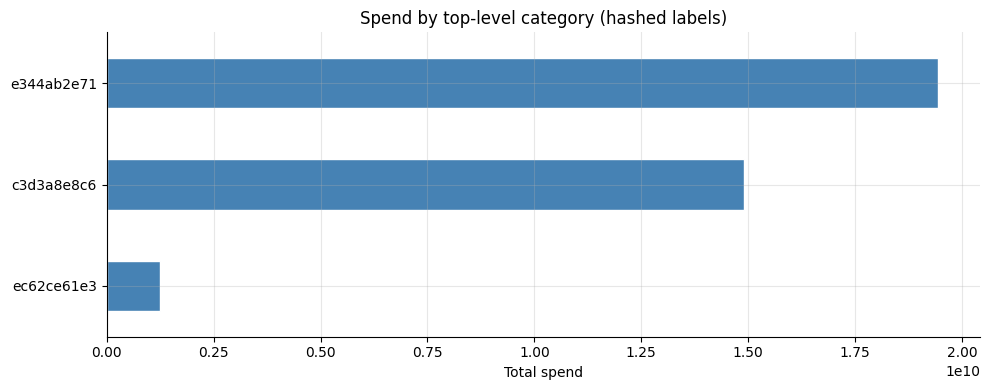

In [ ]:
cat_df = category_spend_by_level(
    DATA_DIR / 'purchases.csv',
    DATA_DIR / 'products.csv',
)
cat_df.plot.barh(color='steelblue', edgecolor='white')
plt.title('Spend by top-level category (hashed labels)')
plt.xlabel('Total spend'); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

**Takeaways:**

1. Despite 43,035 products, spend is concentrated across only 3 hashed top-level
   categories. The dominant category accounts for the overwhelming majority of total
   spend, indicating X5's transaction volume is driven by a single merchandise division
   — almost certainly food/grocery staples. The anonymisation prevents direct
   interpretation, but the spend concentration is itself informative.

2. Since category labels are unreadable, the product file's analytical value for
   Phase 2 lies entirely in its structured binary fields. Per-client ratios of
   `is_alcohol` purchases and `is_own_trademark` purchases (X5's private label products)
   are the two interpretable product-level signals worth engineering into the feature
   matrix — own-brand purchasing, for instance, may proxy for price sensitivity, which
   could correlate with SMS responsiveness.

#### Part 5: Output Validation & Export

**5.1 Submission format check**

In [ ]:
print('Submission format:'); display(sample_sub.head())
print(f'Test set size:    {len(upl_test):,}')
print(f'Submission size:  {len(sample_sub):,}')
print(f'Match: {len(upl_test) == len(sample_sub)}')

test_with_history = upl_test.merge(purch_agg[['client_id']],
                                   on='client_id', how='inner')
print(f'Test clients with history: {len(test_with_history):,} / {len(upl_test):,}')

Submission format:


,client_id,uplift
0,008fb49e3a,0.114991
1,0095340acc,0.835321
2,015c0b4d79,0.308584
3,017ec51c8e,0.415716
4,01bbc5ff71,0.034669


Test set size:    200,123
Submission size:  200,123
Match: True
Test clients with history: 200,123 / 200,123


**5.2 Master table export**

In [ ]:
master_train_path = OUTPUT_DIR / 'master_train.csv'
master_test_path = OUTPUT_DIR / 'master_test.csv'

master.to_csv(master_train_path, index=False)

master_test = upl_test.merge(clients, on='client_id', how='left') \
                      .merge(purch_agg, on='client_id', how='left')
master_test.to_csv(master_test_path, index=False)

print('master_train shape:', master.shape)
print('master_test shape: ', master_test.shape)
print(f'Saved: {master_train_path}')
print(f'Saved: {master_test_path}')

master_train shape: (200039, 25)
master_test shape:  (200123, 22)


#### Part 6: Phase 1 Summary

The following findings from Phase 1 directly motivate the modeling choices in Phase 2:

| Finding                                                           | Implication for Phase 2                                                                 |
| :---------------------------------------------------------------- | :-------------------------------------------------------------------------------------- |
| Experiment is well randomized (ratio ≈ 1.00, balanced RFM)        | Uplift estimates are causally valid — no need for covariate adjustment                  |
| Baseline uplift = 3.32 pp (low average)                           | Heterogeneity is key — uplift model will outperform CCP on subgroup targeting           |
| Uplift highest in lowest frequency deciles (4.4 pp vs 1.6 pp)     | Frequency is a strong predictor of persuadability — include as top feature              |
| 30.2% of clients are Sure Things                                  | CCP model wastes budget here; uplift model should exclude them                          |
| Age column has corrupt values (min=−7,491)                        | Cleaned to [0,100]; age_flagged added as auxiliary feature                              |
| Category hierarchy is hashed (only 3 level_1 values)              | Use is_alcohol, is_own_trademark, netto as product-level features instead               |
| All test clients have purchase history                            | No imputation needed for Phase 2 feature matrix                                         |